# Analiza Free Spoken Digit Dataset (FSDD)

Ten notatnik analizuje zbiór danych Free Spoken Digit Dataset (FSDD). 
Cel: Klasyfikacja wypowiadanych cyfr (0-9) przy użyciu dwóch różnych metod ekstrakcji cech i standardowych modeli uczenia maszynowego (bez sieci neuronowych).

**Metody ekstrakcji cech:**
1. Ręczna/Spektralna: MFCC (Mel-frequency cepstral coefficients).
2. Redukcja wymiarowości: PCA na surowych Mel-spektrogramach.

**Modele:** SVM, Las Losowy (Random Forest), KNN.

## 1. Importy i konfiguracja
Importowanie niezbędnych bibliotek do przetwarzania dźwięku (librosa), manipulacji danymi (pandas, numpy), wizualizacji (matplotlib, seaborn) i uczenia maszynowego (scikit-learn).

In [1]:
import os
import glob
import numpy as np
import pandas as pd
import librosa
import matplotlib.pyplot as plt
import seaborn as sns
import kagglehub

from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score, confusion_matrix


/home/mici/Documents/pk/zmum/zmum_project2/.venv/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


## 2. Ładowanie danych
Pobieranie zbioru danych (jeśli nie jest jeszcze w pamięci podręcznej) i ładowanie plików audio. 
Parsujemy nazwę pliku, aby wyodrębnić etykietę (cyfrę). Dźwięk jest ładowany z częstotliwością 22050Hz.

In [2]:
# Download/Locate dataset
path = kagglehub.dataset_download("joserzapata/free-spoken-digit-dataset-fsdd")
recordings_path = os.path.join(path, "recordings")
print(f"Dataset located at: {recordings_path}")

# Get all .wav files
files = glob.glob(os.path.join(recordings_path, "*.wav"))

data = []
labels = []
max_len = 0

# Load files
for f in files:
    # Filename format: {digit}_{speaker}_{index}.wav
    filename = os.path.basename(f)
    digit = int(filename.split('_')[0])
    
    # Load audio
    y, sr = librosa.load(f, sr=None)
    
    data.append(y)
    labels.append(digit)
    
    if len(y) > max_len:
        max_len = len(y)

print(f"Loaded {len(data)} files.")
print(f"Max audio length: {max_len} samples.")

Dataset located at: /home/mici/.cache/kagglehub/datasets/joserzapata/free-spoken-digit-dataset-fsdd/versions/1/recordings


Loaded 3000 files.
Max audio length: 18262 samples.


## 3. Metoda ekstrakcji cech 1: MFCC
Obliczanie współczynników cepstralnych w skali melowej (MFCC). 
Ponieważ klipy audio różnią się długością, obliczamy **średnią** i **odchylenie standardowe** MFCC w czasie, aby uzyskać wektor cech o stałym rozmiarze dla każdej próbki.

In [3]:
def extract_features_mfcc(audio_data, sr=8000, n_mfcc=13):
    features = []
    for y in audio_data:
        # Compute MFCCs
        mfcc = librosa.feature.mfcc(y=y, sr=sr, n_mfcc=n_mfcc)
        # Transpose to (time, n_mfcc)
        mfcc = mfcc.T
        
        # Calculate mean and std for each coefficient across time
        mean = np.mean(mfcc, axis=0)
        std = np.std(mfcc, axis=0)
        
        # Concatenate mean and std
        feature_vector = np.concatenate((mean, std))
        features.append(feature_vector)
    return np.array(features)

# Extract features
X_mfcc = extract_features_mfcc(data)
y_labels = np.array(labels)

print(f"MFCC Feature shape: {X_mfcc.shape}")

/home/mici/Documents/pk/zmum/zmum_project2/.venv/lib/python3.12/site-packages/librosa/core/spectrum.py:266: UserWarning: n_fft=2048 is too large for input signal of length=1915
  warnings.warn(
/home/mici/Documents/pk/zmum/zmum_project2/.venv/lib/python3.12/site-packages/librosa/core/spectrum.py:266: UserWarning: n_fft=2048 is too large for input signal of length=1988
  warnings.warn(
/home/mici/Documents/pk/zmum/zmum_project2/.venv/lib/python3.12/site-packages/librosa/core/spectrum.py:266: UserWarning: n_fft=2048 is too large for input signal of length=1890
  warnings.warn(
/home/mici/Documents/pk/zmum/zmum_project2/.venv/lib/python3.12/site-packages/librosa/core/spectrum.py:266: UserWarning: n_fft=2048 is too large for input signal of length=1903
  warnings.warn(
/home/mici/Documents/pk/zmum/zmum_project2/.venv/lib/python3.12/site-packages/librosa/core/spectrum.py:266: UserWarning: n_fft=2048 is too large for input signal of length=1772
  warnings.warn(
/home/mici/Documents/pk/zmum/z

/home/mici/Documents/pk/zmum/zmum_project2/.venv/lib/python3.12/site-packages/librosa/core/spectrum.py:266: UserWarning: n_fft=2048 is too large for input signal of length=2020
  warnings.warn(
/home/mici/Documents/pk/zmum/zmum_project2/.venv/lib/python3.12/site-packages/librosa/core/spectrum.py:266: UserWarning: n_fft=2048 is too large for input signal of length=1914
  warnings.warn(
/home/mici/Documents/pk/zmum/zmum_project2/.venv/lib/python3.12/site-packages/librosa/core/spectrum.py:266: UserWarning: n_fft=2048 is too large for input signal of length=1774
  warnings.warn(
/home/mici/Documents/pk/zmum/zmum_project2/.venv/lib/python3.12/site-packages/librosa/core/spectrum.py:266: UserWarning: n_fft=2048 is too large for input signal of length=1790
  warnings.warn(
/home/mici/Documents/pk/zmum/zmum_project2/.venv/lib/python3.12/site-packages/librosa/core/spectrum.py:266: UserWarning: n_fft=2048 is too large for input signal of length=1712
  warnings.warn(
/home/mici/Documents/pk/zmum/z

/home/mici/Documents/pk/zmum/zmum_project2/.venv/lib/python3.12/site-packages/librosa/core/spectrum.py:266: UserWarning: n_fft=2048 is too large for input signal of length=1568
  warnings.warn(
/home/mici/Documents/pk/zmum/zmum_project2/.venv/lib/python3.12/site-packages/librosa/core/spectrum.py:266: UserWarning: n_fft=2048 is too large for input signal of length=1880
  warnings.warn(
/home/mici/Documents/pk/zmum/zmum_project2/.venv/lib/python3.12/site-packages/librosa/core/spectrum.py:266: UserWarning: n_fft=2048 is too large for input signal of length=2044
  warnings.warn(
/home/mici/Documents/pk/zmum/zmum_project2/.venv/lib/python3.12/site-packages/librosa/core/spectrum.py:266: UserWarning: n_fft=2048 is too large for input signal of length=1837
  warnings.warn(
/home/mici/Documents/pk/zmum/zmum_project2/.venv/lib/python3.12/site-packages/librosa/core/spectrum.py:266: UserWarning: n_fft=2048 is too large for input signal of length=1632
  warnings.warn(
/home/mici/Documents/pk/zmum/z

/home/mici/Documents/pk/zmum/zmum_project2/.venv/lib/python3.12/site-packages/librosa/core/spectrum.py:266: UserWarning: n_fft=2048 is too large for input signal of length=1960
  warnings.warn(
/home/mici/Documents/pk/zmum/zmum_project2/.venv/lib/python3.12/site-packages/librosa/core/spectrum.py:266: UserWarning: n_fft=2048 is too large for input signal of length=1531
  warnings.warn(
/home/mici/Documents/pk/zmum/zmum_project2/.venv/lib/python3.12/site-packages/librosa/core/spectrum.py:266: UserWarning: n_fft=2048 is too large for input signal of length=1884
  warnings.warn(
/home/mici/Documents/pk/zmum/zmum_project2/.venv/lib/python3.12/site-packages/librosa/core/spectrum.py:266: UserWarning: n_fft=2048 is too large for input signal of length=1854
  warnings.warn(
/home/mici/Documents/pk/zmum/zmum_project2/.venv/lib/python3.12/site-packages/librosa/core/spectrum.py:266: UserWarning: n_fft=2048 is too large for input signal of length=1906
  warnings.warn(
/home/mici/Documents/pk/zmum/z

/home/mici/Documents/pk/zmum/zmum_project2/.venv/lib/python3.12/site-packages/librosa/core/spectrum.py:266: UserWarning: n_fft=2048 is too large for input signal of length=1597
  warnings.warn(
/home/mici/Documents/pk/zmum/zmum_project2/.venv/lib/python3.12/site-packages/librosa/core/spectrum.py:266: UserWarning: n_fft=2048 is too large for input signal of length=1838
  warnings.warn(
/home/mici/Documents/pk/zmum/zmum_project2/.venv/lib/python3.12/site-packages/librosa/core/spectrum.py:266: UserWarning: n_fft=2048 is too large for input signal of length=1541
  warnings.warn(
/home/mici/Documents/pk/zmum/zmum_project2/.venv/lib/python3.12/site-packages/librosa/core/spectrum.py:266: UserWarning: n_fft=2048 is too large for input signal of length=1295
  warnings.warn(
/home/mici/Documents/pk/zmum/zmum_project2/.venv/lib/python3.12/site-packages/librosa/core/spectrum.py:266: UserWarning: n_fft=2048 is too large for input signal of length=1843
  warnings.warn(
/home/mici/Documents/pk/zmum/z

...

/home/mici/Documents/pk/zmum/zmum_project2/.venv/lib/python3.12/site-packages/librosa/core/spectrum.py:266: UserWarning: n_fft=2048 is too large for input signal of length=2033
  warnings.warn(
/home/mici/Documents/pk/zmum/zmum_project2/.venv/lib/python3.12/site-packages/librosa/core/spectrum.py:266: UserWarning: n_fft=2048 is too large for input signal of length=1953
  warnings.warn(
/home/mici/Documents/pk/zmum/zmum_project2/.venv/lib/python3.12/site-packages/librosa/core/spectrum.py:266: UserWarning: n_fft=2048 is too large for input signal of length=1556
  warnings.warn(
/home/mici/Documents/pk/zmum/zmum_project2/.venv/lib/python3.12/site-packages/librosa/core/spectrum.py:266: UserWarning: n_fft=2048 is too large for input signal of length=1807
  warnings.warn(
/home/mici/Documents/pk/zmum/zmum_project2/.venv/lib/python3.12/site-packages/librosa/core/spectrum.py:266: UserWarning: n_fft=2048 is too large for input signal of length=2027
  warnings.warn(
/home/mici/Documents/pk/zmum/z

/home/mici/Documents/pk/zmum/zmum_project2/.venv/lib/python3.12/site-packages/librosa/core/spectrum.py:266: UserWarning: n_fft=2048 is too large for input signal of length=1547
  warnings.warn(
/home/mici/Documents/pk/zmum/zmum_project2/.venv/lib/python3.12/site-packages/librosa/core/spectrum.py:266: UserWarning: n_fft=2048 is too large for input signal of length=1634
  warnings.warn(
/home/mici/Documents/pk/zmum/zmum_project2/.venv/lib/python3.12/site-packages/librosa/core/spectrum.py:266: UserWarning: n_fft=2048 is too large for input signal of length=1593
  warnings.warn(


/home/mici/Documents/pk/zmum/zmum_project2/.venv/lib/python3.12/site-packages/librosa/core/spectrum.py:266: UserWarning: n_fft=2048 is too large for input signal of length=1149
  warnings.warn(
/home/mici/Documents/pk/zmum/zmum_project2/.venv/lib/python3.12/site-packages/librosa/core/spectrum.py:266: UserWarning: n_fft=2048 is too large for input signal of length=1433
  warnings.warn(
/home/mici/Documents/pk/zmum/zmum_project2/.venv/lib/python3.12/site-packages/librosa/core/spectrum.py:266: UserWarning: n_fft=2048 is too large for input signal of length=1288
  warnings.warn(
/home/mici/Documents/pk/zmum/zmum_project2/.venv/lib/python3.12/site-packages/librosa/core/spectrum.py:266: UserWarning: n_fft=2048 is too large for input signal of length=1785
  warnings.warn(
/home/mici/Documents/pk/zmum/zmum_project2/.venv/lib/python3.12/site-packages/librosa/core/spectrum.py:266: UserWarning: n_fft=2048 is too large for input signal of length=1697
  warnings.warn(
/home/mici/Documents/pk/zmum/z

MFCC Feature shape: (3000, 26)


/home/mici/Documents/pk/zmum/zmum_project2/.venv/lib/python3.12/site-packages/librosa/core/spectrum.py:266: UserWarning: n_fft=2048 is too large for input signal of length=1978
  warnings.warn(
/home/mici/Documents/pk/zmum/zmum_project2/.venv/lib/python3.12/site-packages/librosa/core/spectrum.py:266: UserWarning: n_fft=2048 is too large for input signal of length=1443
  warnings.warn(
/home/mici/Documents/pk/zmum/zmum_project2/.venv/lib/python3.12/site-packages/librosa/core/spectrum.py:266: UserWarning: n_fft=2048 is too large for input signal of length=1446
  warnings.warn(
/home/mici/Documents/pk/zmum/zmum_project2/.venv/lib/python3.12/site-packages/librosa/core/spectrum.py:266: UserWarning: n_fft=2048 is too large for input signal of length=1682
  warnings.warn(
/home/mici/Documents/pk/zmum/zmum_project2/.venv/lib/python3.12/site-packages/librosa/core/spectrum.py:266: UserWarning: n_fft=2048 is too large for input signal of length=1970
  warnings.warn(


## 4. Metoda ekstrakcji cech 2: Spektrogram + PCA
Najpierw wyrównujemy wszystkie sygnały audio do maksymalnej długości (padding), aby zapewnić jednolity rozmiar.
Następnie obliczamy Mel-spektrogram dla każdego klipu i spłaszczamy go do wektora 1D.
Na koniec używamy analizy głównych składowych (PCA), aby zredukować wymiarowość tych dużych wektorów.

In [4]:
def extract_features_pca(audio_data, max_length, n_components=0.95):
    # Pad audio to max_length
    padded_data = []
    for y in audio_data:
        pad_width = max_length - len(y)
        # Pad with zeros at the end
        padded = np.pad(y, (0, pad_width), mode='constant')
        padded_data.append(padded)
    
    padded_data = np.array(padded_data)
    
    # Compute Spectrograms
    spectrograms = []
    for y in padded_data:
        # Compute Mel Spectrogram
        mels = librosa.feature.melspectrogram(y=y, sr=8000, n_mels=64)
        # Log-Mel Spectrogram (dB)
        mels_db = librosa.power_to_db(mels, ref=np.max)
        # Flatten
        spectrograms.append(mels_db.flatten())
    
    X_flat = np.array(spectrograms)
    
    # Apply PCA
    print(f"Shape before PCA: {X_flat.shape}")
    pca = PCA(n_components=n_components) # Keep 95% variance
    X_pca = pca.fit_transform(X_flat)
    print(f"Shape after PCA: {X_pca.shape}")
    
    return X_pca

# Extract PCA features
X_pca = extract_features_pca(data, max_len)

Shape before PCA: (3000, 2304)


Shape after PCA: (3000, 46)


## 5. Trenowanie modeli i porównanie
Dzielimy oba zestawy danych (MFCC i PCA) na zbiory treningowe i testowe (80/20).
Następnie trenujemy trzy standardowe klasyfikatory (SVM, Las Losowy, KNN) na obu zestawach cech i porównujemy ich dokładność.

In [5]:
def train_and_evaluate(X, y, name_prefix):
    # Split data
    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)
    
    # Scale data (important for SVM and KNN)
    scaler = StandardScaler()
    X_train_scaled = scaler.fit_transform(X_train)
    X_test_scaled = scaler.transform(X_test)
    
    models = {
        "SVM": SVC(),
        "RandomForest": RandomForestClassifier(random_state=42),
        "KNN": KNeighborsClassifier()
    }
    
    results = {}
    
    print(f"--- Results for {name_prefix} ---")
    for name, model in models.items():
        model.fit(X_train_scaled, y_train)
        y_pred = model.predict(X_test_scaled)
        acc = accuracy_score(y_test, y_pred)
        results[name] = acc
        print(f"{name} Accuracy: {acc:.4f}")
    print("\n")
    return results

# Evaluate MFCC features
results_mfcc = train_and_evaluate(X_mfcc, y_labels, "MFCC Features")

# Evaluate PCA features
results_pca = train_and_evaluate(X_pca, y_labels, "PCA Features")

--- Results for MFCC Features ---
SVM Accuracy: 0.9833


RandomForest Accuracy: 0.9633
KNN Accuracy: 0.9733


--- Results for PCA Features ---


SVM Accuracy: 0.9683


RandomForest Accuracy: 0.9617
KNN Accuracy: 0.9383




## 6. Optymalizacja
Wybieramy najlepiej działającą kombinację (np. SVM z MFCC) i optymalizujemy jej hiperparametry za pomocą `GridSearchCV`.

In [6]:
# Data splitting for optimization (using MFCCs as they are typically robust)
X_train, X_test, y_train, y_test = train_test_split(X_mfcc, y_labels, test_size=0.2, random_state=42, stratify=y_labels)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Define parameter grid for SVM
param_grid = {
    'C': [0.1, 1, 10, 100],
    'gamma': ['scale', 'auto', 0.1, 0.01],
    'kernel': ['rbf', 'linear']
}

grid = GridSearchCV(SVC(), param_grid, cv=5, verbose=1, n_jobs=-1)
grid.fit(X_train_scaled, y_train)

print(f"Best Parameters: {grid.best_params_}")
print(f"Best Cross-Validation Score: {grid.best_score_:.4f}")

# Evaluate on test set
best_model = grid.best_estimator_
y_pred_opt = best_model.predict(X_test_scaled)
print(f"Test Set Accuracy (Optimized): {accuracy_score(y_test, y_pred_opt):.4f}")

Fitting 5 folds for each of 32 candidates, totalling 160 fits


Best Parameters: {'C': 10, 'gamma': 0.1, 'kernel': 'rbf'}
Best Cross-Validation Score: 0.9829
Test Set Accuracy (Optimized): 0.9783


## 7. Wizualizacja wyników
Wyświetlanie macierzy pomyłek (Confusion Matrix) dla zoptymalizowanego modelu w celu analizy błędów klasyfikacji.

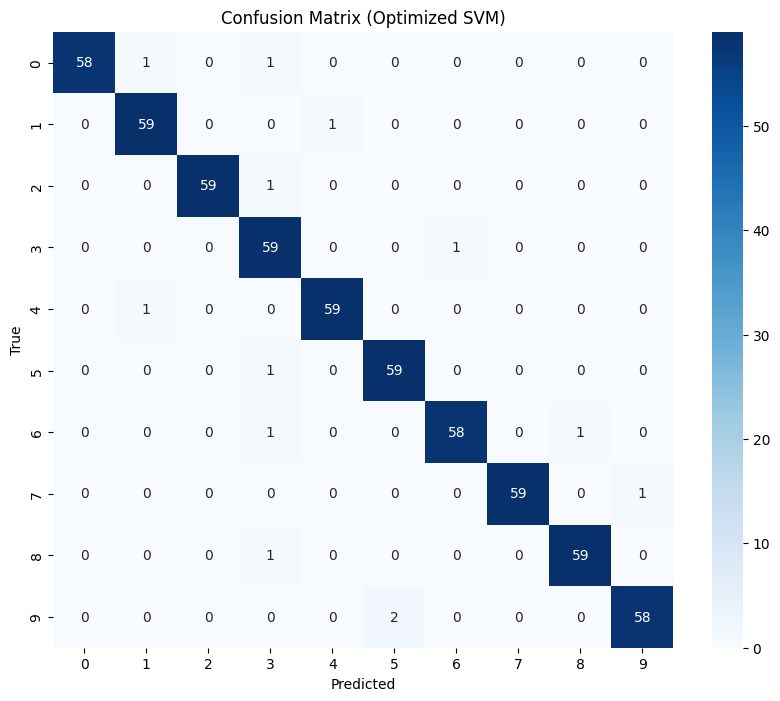

In [7]:
cm = confusion_matrix(y_test, y_pred_opt)
plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.xlabel('Predicted')
plt.ylabel('True')
plt.title('Confusion Matrix (Optimized SVM)')
plt.show()